In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns

from ex_01_read_data import get_welding_data
from ex_03_feature_extraction import extract_features

In [2]:
data_path = Path("data/Welding/data.csv")
plot_path = Path("plots/ex_03")
plot_path.mkdir(parents=True, exist_ok=True)

## Exercise 3.3: Feature Exploration with Pairplots

In this exercise, you will create a seaborn pairplot to visualize relationships between the features extracted from the welding data. 

In [3]:
n_samples = 1_000
data, labels, _ = get_welding_data(data_path, n_samples=n_samples)
features = extract_features(data, labels)
features.head()

,current_mean,current_std,current_min,current_max,current_median,current_rms,current_skew,current_kurtosis,current_range,current_dom_freq,...,voltage_max,voltage_median,voltage_rms,voltage_skew,voltage_kurtosis,voltage_range,voltage_dom_freq,voltage_skewness,voltage_kurt_manual,label
0,177.744210,143.224222,29.109549,498.528970,138.398691,228.267786,1.255446,0.394152,469.419421,10.0,...,29.571896,15.673120,16.725640,-0.156073,-1.196599,27.869220,5.0,-0.154900,-1.196743,1
1,162.623063,181.892607,38.004867,533.703336,45.616540,243.990125,1.186696,-0.250486,495.698470,5.0,...,30.304668,19.662713,22.182480,0.963945,-0.607392,12.616025,5.0,0.956700,-0.622164,0
2,167.716916,176.811505,28.564925,533.560615,71.404167,243.703246,1.135897,-0.231826,504.995689,5.0,...,33.203770,23.625500,25.670098,1.052026,-0.085958,13.520587,5.0,1.044120,-0.113675,0
3,162.313872,182.349021,35.981339,535.219064,45.463319,244.124884,1.186131,-0.250361,499.237725,5.0,...,32.967376,19.722266,23.078240,0.447374,-0.382829,26.776788,5.0,0.444012,-0.403176,1
4,168.199606,185.263173,36.111874,540.879528,48.040659,250.226998,1.141208,-0.357789,504.767653,5.0,...,32.451631,19.344496,22.710459,0.233443,0.138810,26.027272,35.0,0.231689,0.105513,1


Top 5 features by F-score:
           feature           F
17     voltage_rms  171.387826
12    voltage_mean  166.027028
16  voltage_median  152.124224
14     voltage_min  150.734534
20   voltage_range   95.968372


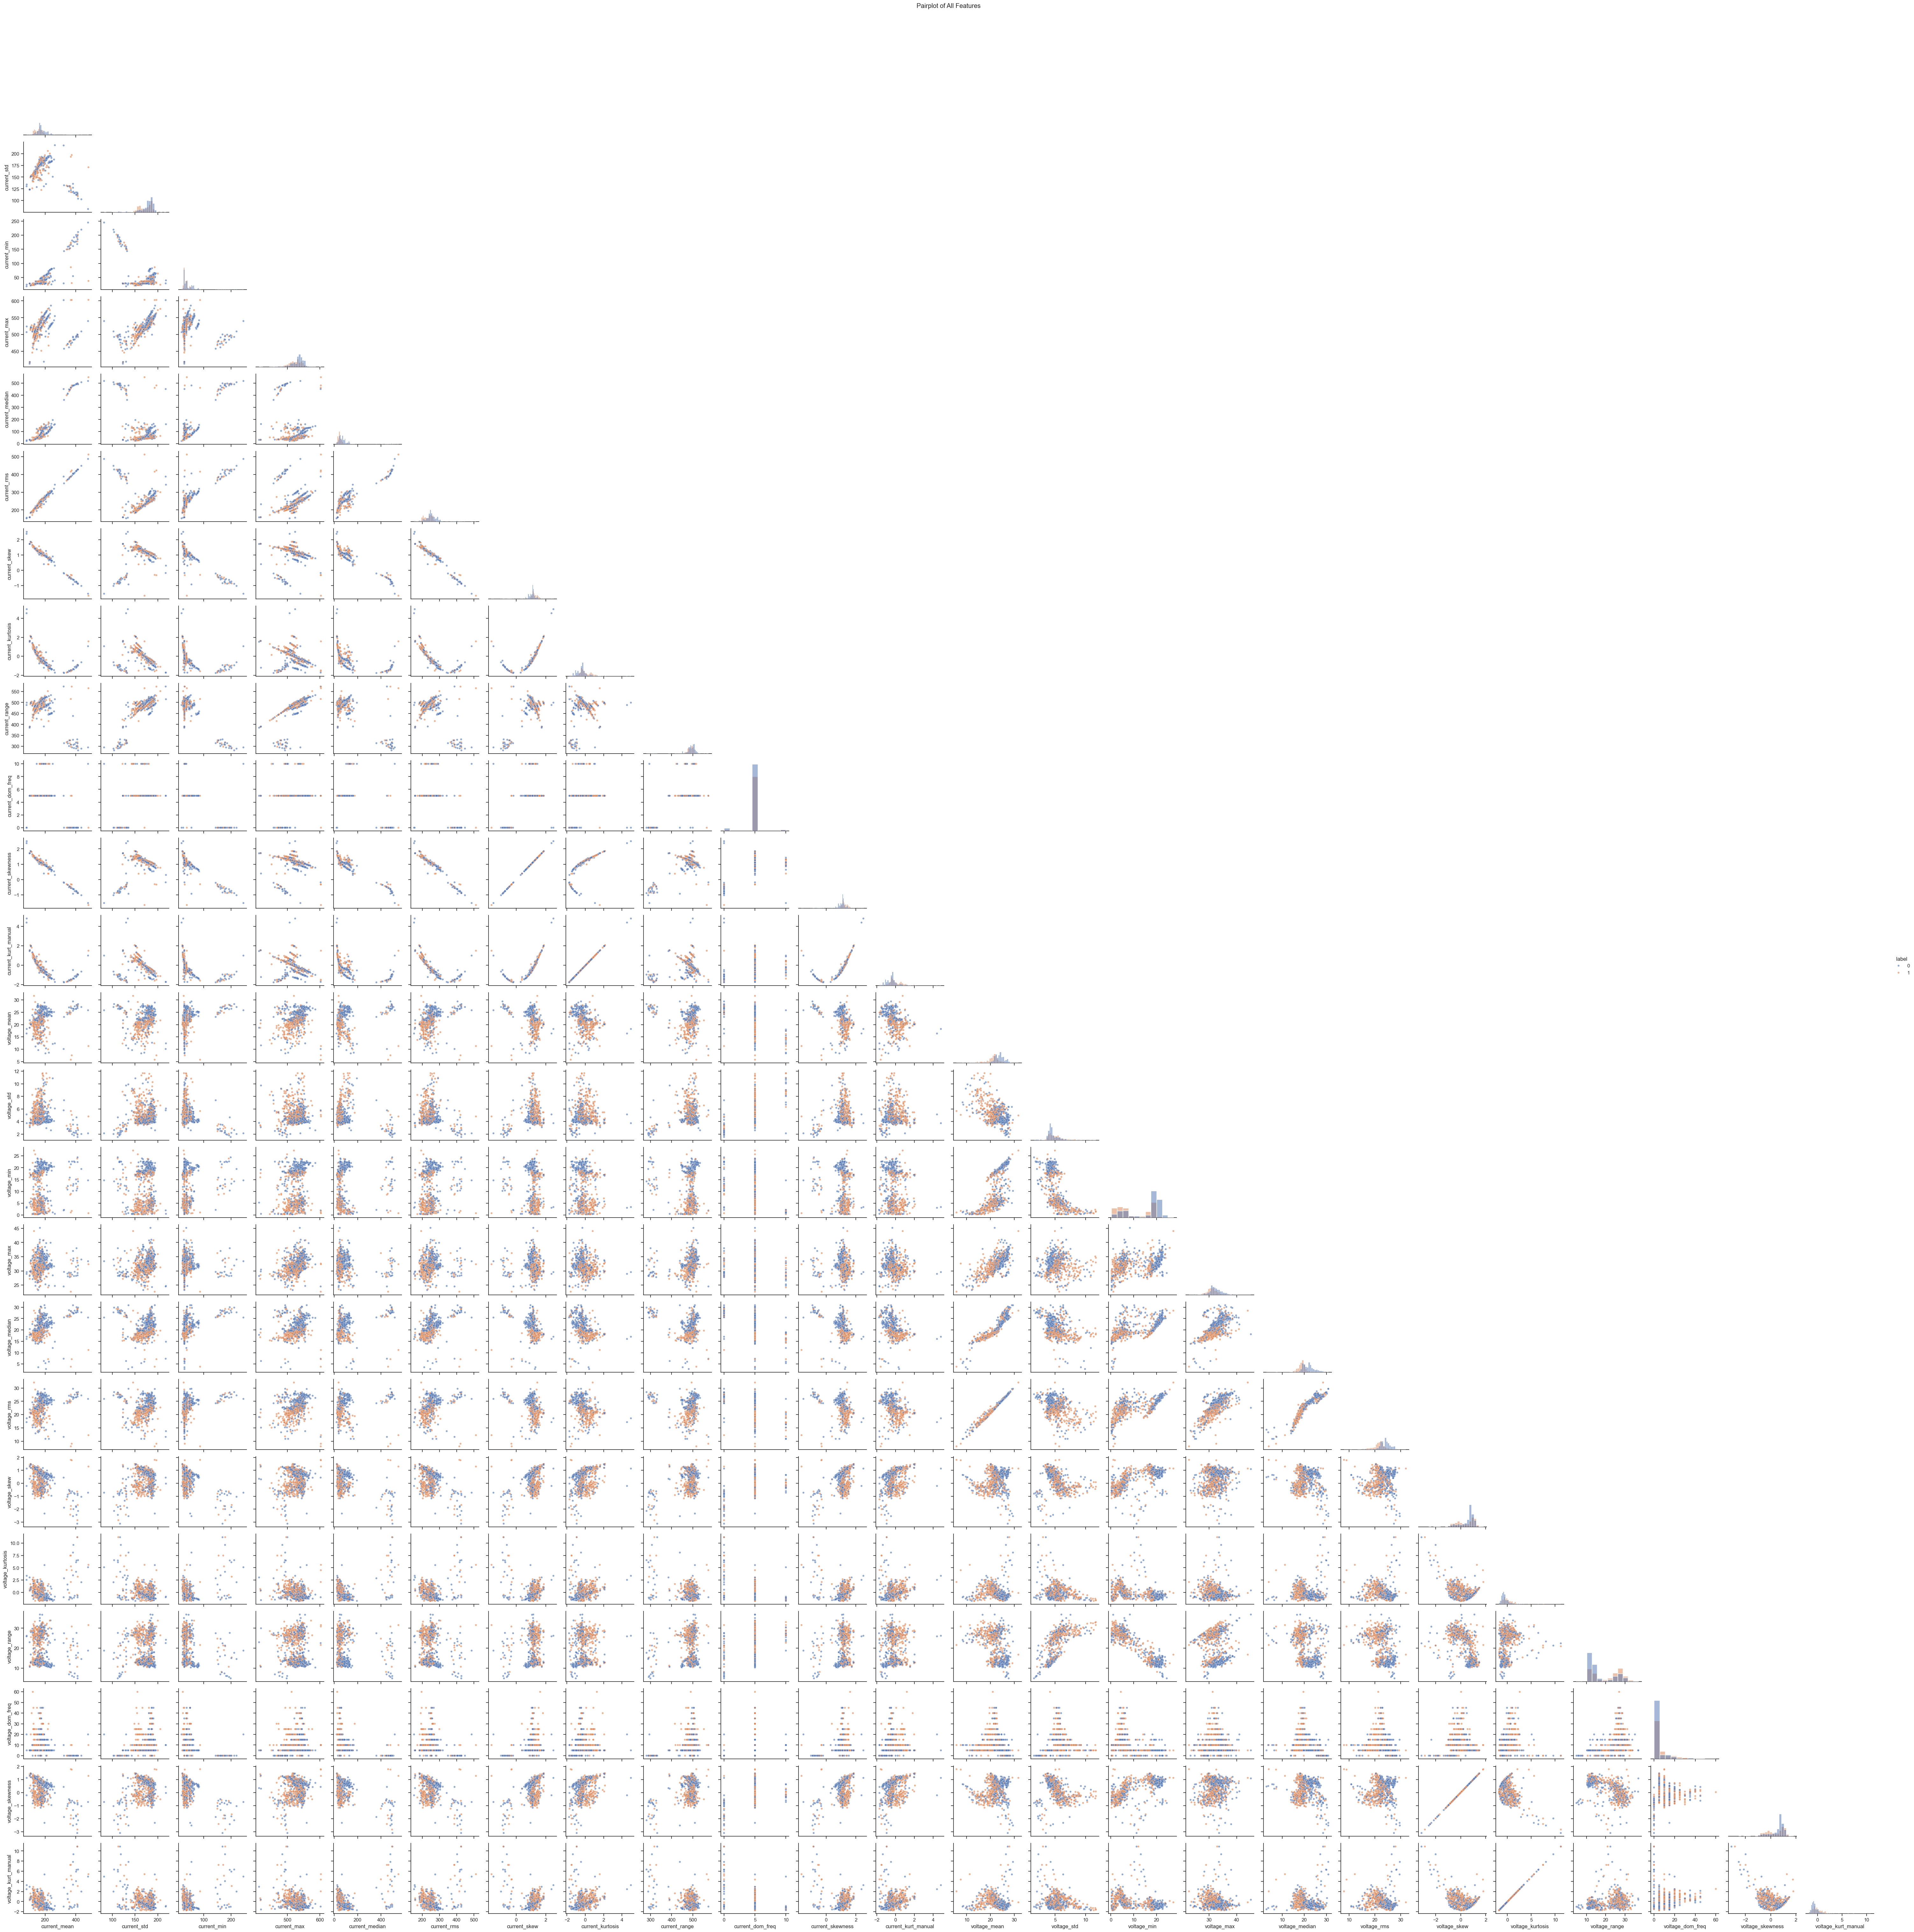

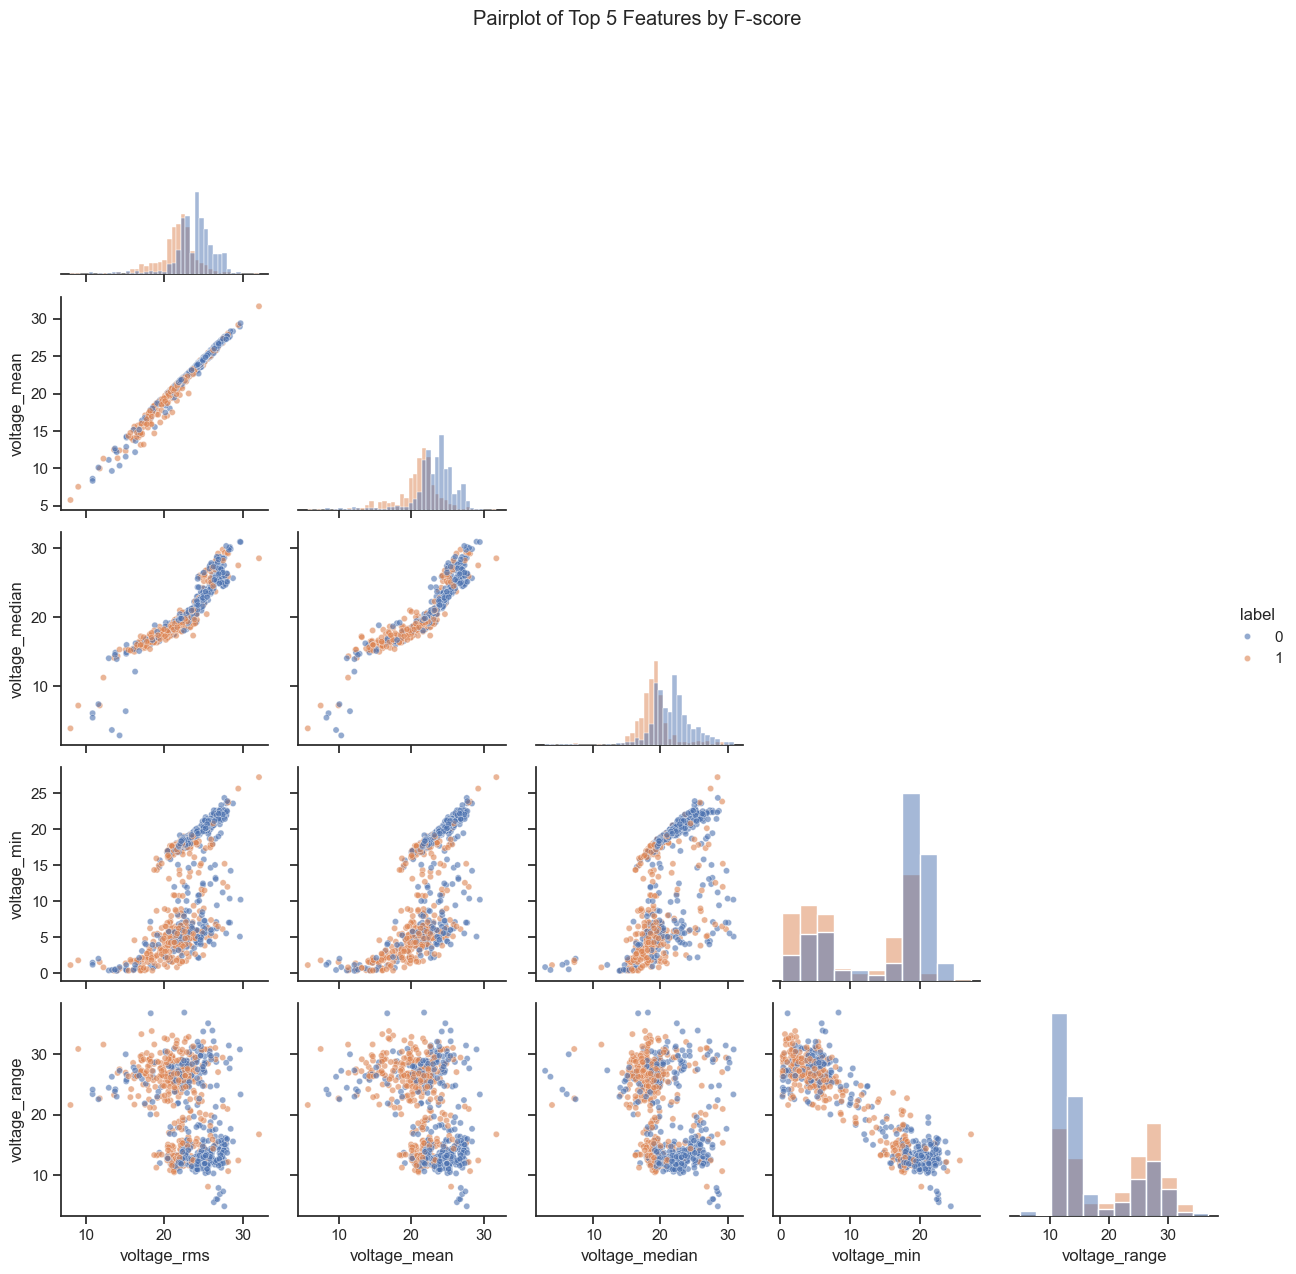

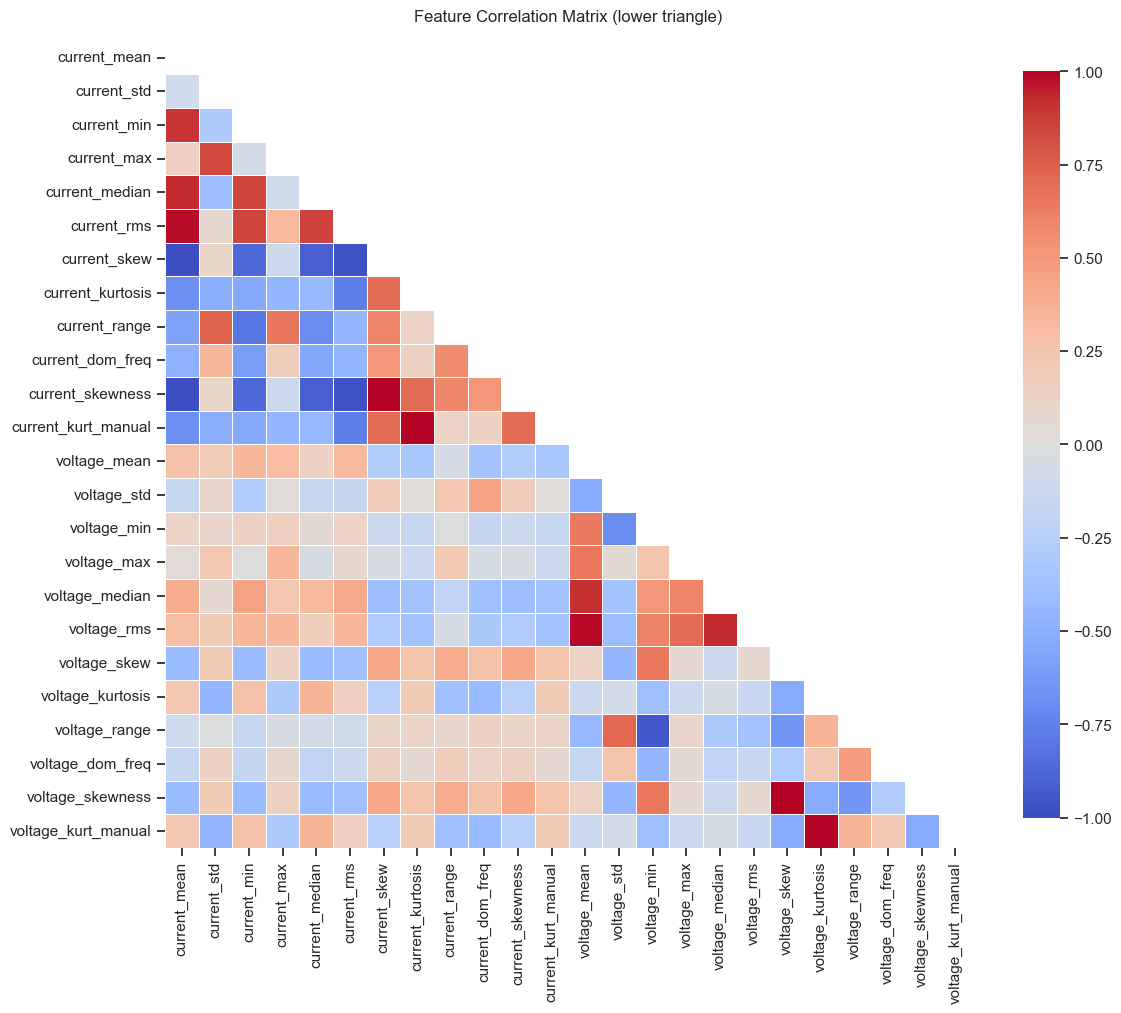


Highly correlated feature pairs (|r| ≥ 0.85):
       feature_1           feature_2  correlation
current_kurtosis current_kurt_manual     1.000000
    voltage_skew    voltage_skewness     1.000000
voltage_kurtosis voltage_kurt_manual     1.000000
    current_skew    current_skewness     1.000000
    voltage_mean         voltage_rms     0.989964
    current_mean        current_skew     0.985809
    current_mean    current_skewness     0.985809
    current_mean         current_rms     0.983237
     current_rms    current_skewness     0.970855
     current_rms        current_skew     0.970855
     voltage_min       voltage_range     0.939648
  voltage_median         voltage_rms     0.929680
    current_mean      current_median     0.923233
    voltage_mean      voltage_median     0.914046
  current_median        current_skew     0.913137
  current_median    current_skewness     0.913137
    current_mean         current_min     0.893654
     current_min    current_skewness     0.872778
   

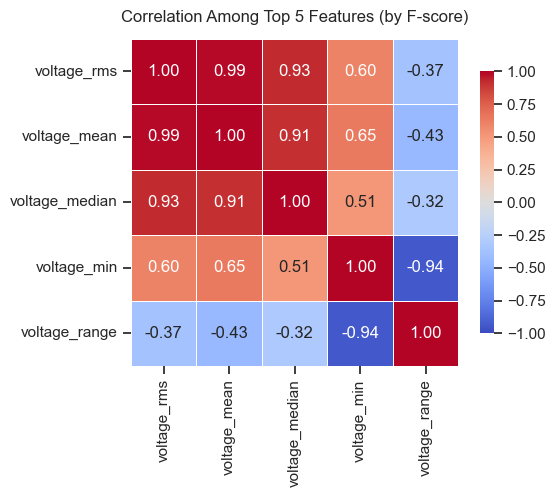

In [28]:
from sklearn.feature_selection import f_classif

feature_columns = [col for col in features.columns if col != "label"]
X = features[feature_columns]
y = features["label"]

# ── ANOVA F-scores ──────────────────────────────────────────────────────────
F, p = f_classif(X, y)
scores = pd.DataFrame({"feature": feature_columns, "F": F}).sort_values("F", ascending=False)

K = 5
top_features = scores["feature"].head(K).tolist()
print(f"Top {K} features by F-score:\n{scores.head(K)}")

# ── Pairplot: ALL features ───────────────────────────────────────────────────
all_data = features[feature_columns + ["label"]]
sns.set_theme(style="ticks")

g_all = sns.PairGrid(all_data, vars=feature_columns, hue="label", corner=True)
g_all.map_lower(sns.scatterplot, alpha=0.6, s=20)
g_all.map_diag(sns.histplot)
g_all.add_legend()
g_all.fig.suptitle("Pairplot of All Features", y=1.02)
g_all.fig.savefig(plot_path / "pairplot_all_features.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Pairplot: Top K features ─────────────────────────────────────────────────
top_data = features[top_features + ["label"]]

g_top = sns.PairGrid(top_data, vars=top_features, hue="label", corner=True)
g_top.map_lower(sns.scatterplot, alpha=0.6, s=20)
g_top.map_diag(sns.histplot)
g_top.add_legend()
g_top.fig.suptitle(f"Pairplot of Top {K} Features by F-score", y=1.02)
g_top.fig.savefig(plot_path / f"pairplot_top{K}_features.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Correlation heatmap: ALL features ────────────────────────────────────────
CORR_THRESHOLD = 0.85
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(max(8, len(feature_columns) * 0.5),
                                 max(6, len(feature_columns) * 0.45)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask,
            annot=len(feature_columns) <= 20, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.4, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature Correlation Matrix (lower triangle)", pad=14)
plt.tight_layout()
fig.savefig(plot_path / "corr_heatmap_all_features.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Highly correlated pairs + greedy drop suggestion ─────────────────────────
corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack().reset_index()
         .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
         .query("correlation >= @CORR_THRESHOLD")
         .sort_values("correlation", ascending=False)
)

print(f"\nHighly correlated feature pairs (|r| ≥ {CORR_THRESHOLD}):")
if high_corr_pairs.empty:
    print("  None found — no redundant features detected at this threshold.")
else:
    print(high_corr_pairs.to_string(index=False))

f_score_map = scores.set_index("feature")["F"].to_dict()
to_drop = set()
for _, row in high_corr_pairs.iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]
    if f1 in to_drop or f2 in to_drop:
        continue
    weaker = f1 if f_score_map.get(f1, 0) < f_score_map.get(f2, 0) else f2
    to_drop.add(weaker)

if to_drop:
    print(f"\nSuggested features to drop (redundant + weaker F-score):")
    for feat in sorted(to_drop):
        print(f"  • {feat}  (F = {f_score_map.get(feat, float('nan')):.2f})")
    retained = [f for f in feature_columns if f not in to_drop]
    print(f"\nRetained features after removing redundancy: {len(retained)}/{len(feature_columns)}")
else:
    print("\nNo features suggested for removal.")

# ── Correlation heatmap: Top K features ──────────────────────────────────────
top_corr = features[top_features].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(top_corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title(f"Correlation Among Top {K} Features (by F-score)", pad=12)
plt.tight_layout()
fig.savefig(plot_path / f"corr_heatmap_top{K}_features.png", bbox_inches="tight", dpi=150)
plt.show()

## Exercise 3.4: Describe Your Feature Selection

Based on the pairplot visualization from Exercise 3.1, provide a detailed analysis of your feature selection:

1. Which features appear most effective at separating the quality classes?
2. Are there features that show strong correlation with each other? Would it make sense to remove any redundant features?
3. Explain the physical significance of your selected features in the context of welding quality.
4. If you were to select a subset of 5 most important features for classifying welding quality, which would you choose and why?
5. Discuss any patterns or insights you discovered in the data visualization that might help with building a classification model.


In [ ]:
"""
1. According F-score test, the top 5 features are: voltage_rms, voltage_mean, voltage_median, voltage_min, and voltage_range.
   I took arbitarily K=5, based on question 4. However the choice of K can be adjusted.
   These features are likely to be the most informative for distinguishing between different classes in the welding data.
2. Yes, for example current_kurtosis, voltage_skew, voltage_kurtosis, and current_skew show high correlation with each other (|r| > 0.85) but have relatively low F-scores compared to the top features.
   This suggests they may be redundant and could potentially be removed.
3. The model relies heavily on these features because they measure the essential heat input (voltage_rms and voltage_mean), 
   baseline process stability (voltage_median), and erratic arc disruptions (voltage_min and voltage_range) that directly dictate weld penetration,
   bead geometry, and defect formation.
4. voltage_rms, voltage_mean, voltage_median, voltage_min, and voltage_range.
5. -
"""